<img src="logoucm.png" style="height: 200px">
<center style="color:#888"><br/></center>


<font size="6"><center style="color:#1B4F72"><br/>
Técnicas de Simulación</center></font>
<font size="4"><center style="color:#1B4F72"><br/>
Máster en Ingeniería Matemática</center></font>

<font size="5"><center><span style="color:#117864">***Nombre y Apellidos: ____________________***</span></center></font>

<font size="5"><center><span style="color:#1B4F72">***Práctica 8: Proceso de Poisson***</span></center></font>

En esta práctica estudiaremos el proceso de Poisson, modelo fundamental en la teoría de procesos estocásticos que describe la ocurrencia aleatoria de eventos en el tiempo. El proceso de Poisson es la base de los sistemas de colas que veremos en la práctica siguiente.

### Importamos las librerías necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

## 1. Definición y Propiedades

Un **proceso de Poisson homogéneo** $\{N(t),\, t \geq 0\}$ de tasa $\lambda > 0$ verifica:

- $N(0) = 0$
- **Incrementos independientes**: para $0 \leq s < t \leq u < v$, $N(t)-N(s)$ y $N(v)-N(u)$ son independientes.
- **Incrementos estacionarios**: $N(s+t) - N(s) \sim \text{Poisson}(\lambda t)$, es decir:

$$\mathbb{P}(N(t) = k) = \frac{(\lambda t)^k e^{-\lambda t}}{k!}, \quad k = 0, 1, 2, \ldots$$

### Propiedades fundamentales

- **Media y varianza**: $\mathbb{E}[N(t)] = \text{Var}(N(t)) = \lambda t$
- **Tiempos interarribo**: los tiempos entre eventos consecutivos $T_i$ son i.i.d. con distribución $\text{Exp}(\lambda)$:
$$T_i \sim \text{Exp}(\lambda) \quad \Rightarrow \quad f_T(t) = \lambda e^{-\lambda t}, \quad t \geq 0$$
- **Tiempo hasta el $n$-ésimo evento**: la suma de $n$ tiempos interarribo sigue una distribución Gamma:
$$S_n = T_1 + T_2 + \cdots + T_n \sim \text{Gamma}(n, \lambda)$$
- **Conexión con las colas**: el proceso de Poisson es el modelo de llegadas del sistema M/M/1 y M/M/c que estudiaremos en la siguiente práctica.

## 2. Simulación de un Proceso de Poisson

### 2.1 Método de simulación

El método más directo para simular un proceso de Poisson en $[0, T]$ consiste en:
1. Generar tiempos interarribo $T_i \sim \text{Exp}(\lambda)$ sucesivamente.
2. Acumular los tiempos $S_n = T_1 + \cdots + T_n$ hasta superar $T$.
3. Los instantes $S_1, S_2, \ldots$ son los tiempos de ocurrencia de los eventos.

In [2]:
def simula_poisson(lambda_, tfinal, semilla=None):
    """Simula un proceso de Poisson de tasa lambda_ en [0, tfinal].
    Devuelve la lista de tiempos de ocurrencia de los eventos."""
    if semilla is not None:
        np.random.seed(semilla)
    t = 0
    tiempos = []
    while True:
        t += np.random.exponential(1 / lambda_)
        if t >= tfinal:
            break
        tiempos.append(t)
    return tiempos

### 2.2 Visualización: diagrama de eventos y proceso de conteo $N(t)$

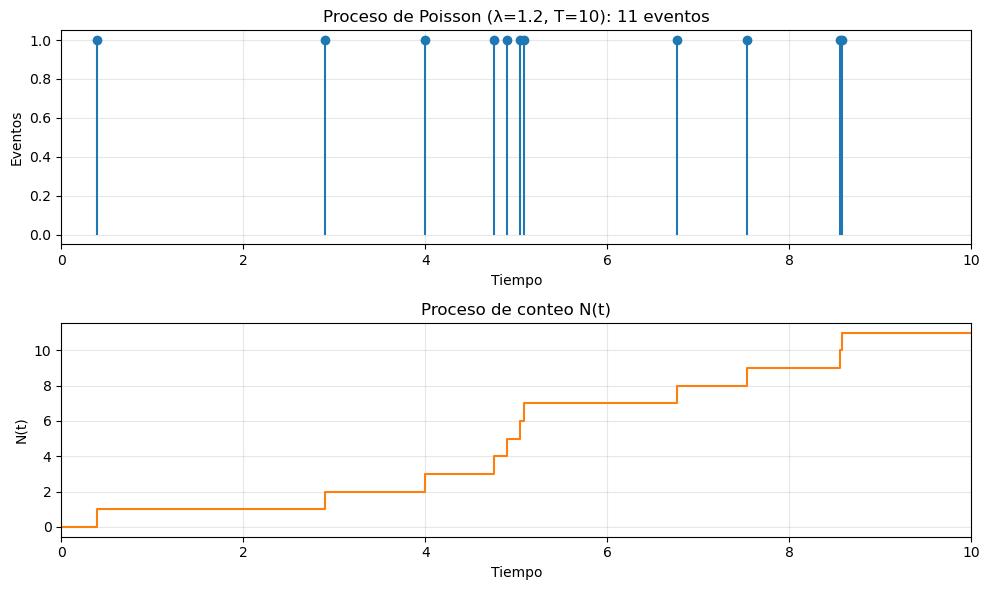

Número de eventos observados: 11
Número esperado (λ·T):        12.0


In [3]:
lambda_ = 1.2
T = 10
tiempos = simula_poisson(lambda_, T, semilla=42)

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Diagrama de eventos
axes[0].stem(tiempos, np.ones(len(tiempos)), basefmt=' ', linefmt='C0-', markerfmt='C0o')
axes[0].set_xlim(0, T)
axes[0].set_title(f"Proceso de Poisson (λ={lambda_}, T={T}): {len(tiempos)} eventos")
axes[0].set_xlabel("Tiempo")
axes[0].set_ylabel("Eventos")
axes[0].grid(True, alpha=0.3)

# Proceso de conteo N(t)
t_plot = [0] + tiempos + [T]
n_plot = list(range(len(tiempos) + 1)) + [len(tiempos)]
axes[1].step(t_plot, n_plot, where='post', color='C1')
axes[1].set_xlim(0, T)
axes[1].set_title("Proceso de conteo N(t)")
axes[1].set_xlabel("Tiempo")
axes[1].set_ylabel("N(t)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Número de eventos observados: {len(tiempos)}")
print(f"Número esperado (λ·T):        {lambda_ * T:.1f}")

## 3. Verificación del número de eventos

Comparamos la distribución empírica del número de eventos $N(T)$ con la distribución teórica $\text{Poisson}(\lambda T)$.

Verificación de media y varianza:
  Media empírica:    12.1460 | Teórica (λT):  12.0000
  Varianza empírica: 12.2067 | Teórica (λT):  12.0000


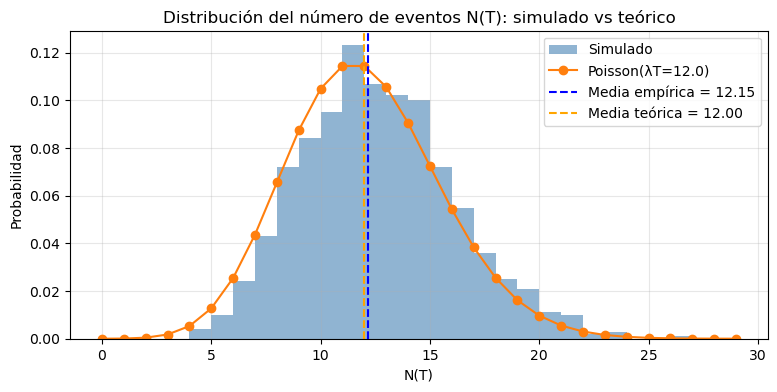

In [4]:
n_sim = 1000
np.random.seed(123)
event_counts = [len(simula_poisson(lambda_, T)) for _ in range(n_sim)]

# Comparación empírica vs teórica
media_empirica = np.mean(event_counts)
var_empirica = np.var(event_counts)
media_teorica = lambda_ * T
var_teorica = lambda_ * T

print("Verificación de media y varianza:")
print(f"  Media empírica:    {media_empirica:.4f} | Teórica (λT):  {media_teorica:.4f}")
print(f"  Varianza empírica: {var_empirica:.4f} | Teórica (λT):  {var_teorica:.4f}")

# Gráfico
x = np.arange(0, 30)
plt.figure(figsize=(9, 4))
plt.hist(event_counts, bins=range(30), density=True, alpha=0.6, label='Simulado', color='steelblue')
plt.plot(x, stats.poisson.pmf(x, lambda_ * T), 'o-', color='C1', label=f'Poisson(λT={lambda_*T})')
plt.axvline(media_empirica, color='blue', linestyle='--', label=f'Media empírica = {media_empirica:.2f}')
plt.axvline(media_teorica, color='orange', linestyle='--', label=f'Media teórica = {media_teorica:.2f}')
plt.legend()
plt.title("Distribución del número de eventos N(T): simulado vs teórico")
plt.xlabel("N(T)")
plt.ylabel("Probabilidad")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Ejercicio 1: Estimación de λ

### 📌 Enunciado
El estimador de máxima verosimilitud de $\lambda$ es:
$$\hat{\lambda} = \frac{N(T)}{T}$$

1. Simula 500 trayectorias del proceso de Poisson con $\lambda = 1.2$ y $T = 10$.
2. Para cada trayectoria, calcula el estimador $\hat{\lambda}$.
3. Representa el histograma de los estimadores y compáralo con el valor real $\lambda = 1.2$.
4. Calcula el sesgo ($\mathbb{E}[\hat{\lambda}] - \lambda$) y el error cuadrático medio.

**Valor de referencia:** el estimador debería concentrarse en torno a $\lambda = 1.2$.

## 5. Ejercicio 2: Tiempos interarribo y distribución Exponencial

### 📌 Enunciado
1. Simula una trayectoria larga del proceso de Poisson con $\lambda = 1.2$ y $T = 1000$.
2. Extrae los tiempos interarribo $T_i = S_i - S_{i-1}$.
3. Representa el histograma de los tiempos interarribo y superpón la función de densidad teórica $f(t) = \lambda e^{-\lambda t}$.
4. Calcula la media muestral de los tiempos interarribo y compárala con el valor teórico $1/\lambda$.
5. Realiza un test de Kolmogorov-Smirnov para verificar que los tiempos siguen una distribución exponencial.

**Valor de referencia:** la media muestral debería aproximarse a $1/\lambda = 1/1.2 \approx 0.833$.

## 6. Ejercicio 3: Independencia de incrementos

### 📌 Enunciado
Una propiedad clave del proceso de Poisson es la independencia de los incrementos: el número de eventos en intervalos disjuntos son variables aleatorias independientes.

1. Simula 500 trayectorias con $\lambda = 1.2$ y $T = 20$.
2. Para cada trayectoria, cuenta los eventos en $[0,10)$ y en $[10,20)$.
3. Calcula el coeficiente de correlación de Pearson entre ambos conteos.
4. Representa el diagrama de dispersión y comenta si los resultados son consistentes con la hipótesis de independencia.

**Valor de referencia:** el coeficiente de correlación debería ser próximo a 0.

## 7. Conclusiones

- El proceso de Poisson modela la ocurrencia aleatoria de eventos en el tiempo con una tasa constante $\lambda$.
- Sus propiedades fundamentales (incrementos independientes y estacionarios, tiempos interarribo exponenciales) son verificables mediante simulación.
- El estimador natural de $\lambda$ es el número de eventos dividido por el tiempo de observación.
- El proceso de Poisson es la base del modelo de llegadas M/M/c de la Teoría de Colas, que estudiaremos en la siguiente práctica.